# BÀI 4 – GOM CỤM (CLUSTERING)


---
#  XÁC ĐỊNH BỘ DỮ LIỆU

 Bài toán Gom cụm (Clustering):
  1. *Đặc thù nghiệp vụ livestream:* Hành vi người xem trong phòng live không có sẵn nhãn định trước trong thực tế (học không giám sát). Người dùng tự nhiên phân hóa thành các nhóm tiêu thụ nội dung khác nhau (người xem lướt qua, người thích tương tác bình luận, người trung thành thả tim, người hâm mộ tặng quà VIP).
  2. *Đa dạng thuộc tính số:* Bộ dữ liệu chứa nhiều chiều đo lường cường độ hành vi (`Watch_Time`, `Click_Count`, `Comment_Count`, `Like_Count`, `Gift_Count`, `Gift_Value`), tạo điều kiện đo lường khoảng cách hình học và mật độ phân bố giữa các quan sát.
  3. *Hỗ trợ phân khúc người dùng (Viewer Segmentation):* Kết quả gom cụm cung cấp các phân khúc đối tượng (viewer personas) phục vụ cá nhân hóa gợi ý luồng phát và tối ưu hóa thời gian giữ chân người xem.


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from IPython.display import display

# Cấu hình giao diện và hiển thị
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

print("Đã nạp đầy đủ các thư viện cần thiết.")


Đã nạp đầy đủ các thư viện cần thiết.


In [ ]:
# Đường dẫn tương đối chuẩn từ thư mục bai4-gom-cum
data_path = "../data/processed/dataset_30_attributes_processed.csv"

df = pd.read_csv(data_path)

print("===== THÔNG TIN TỔNG QUAN VỀ TẬP DỮ LIỆU =====")
print(f"Tên dataset: KuaiLive Viewer Engagement (Processed)")
print(f"Số dòng (samples)   : {df.shape[0]:,}")
print(f"Số cột (attributes) : {df.shape[1]}")
print("\n5 dòng đầu tiên của tập dữ liệu:")
display(df.head(5))


===== THÔNG TIN TỔNG QUAN VỀ TẬP DỮ LIỆU =====
Tên dataset: KuaiLive Viewer Engagement (Processed)
Số dòng (samples)   : 20,000
Số cột (attributes) : 47

5 dòng đầu tiên của tập dữ liệu:
   Viewer_ID  Live_ID  Streamer_ID Viewer_Age Viewer_Gender Viewer_Country Viewer_Device_Brand Viewer_Device_Price  Account_Age_Days Accumulated_Watch_Count Accumulated_Watch_Duration  Is_Live_Streamer  Is_Photo_Author  Watch_Time  Click_Count  Comment_Count  Like_Count  Gift_Count  Gift_Value  Has_Comment  Has_Like  Has_Gift  Interaction_Count  Like_Rate  Comment_Rate  Gift_Rate  Engagement_Score Engagement_Level Streamer_Gender Streamer_Age  Log_Watch_Time  Log_Click_Count  Log_Comment_Count  Log_Like_Count  Log_Gift_Count  Log_Gift_Value  Z_Watch_Time  Z_Click_Count  Z_Comment_Count  Z_Like_Count  Z_Gift_Count  Z_Gift_Value Watch_Time_Level Like_Behavior Comment_Behavior Gift_Behavior Gift_Value_Level
0          1  1520913       285858      24-30             F          China              HUAWEI     

---
# TIỀN XỬ LÝ VÀ CHỌN LỌC ĐẶC TRƯNG

Trong bài toán gom cụm, việc chọn lọc và tiền xử lý đặc trưng cần tuân thủ các nguyên tắc kỹ thuật sau:
1. **Loại bỏ thuộc tính định danh (ID):** Các cột `Viewer_ID`, `Live_ID`, `Streamer_ID` là khóa đại diện thực thể, không mang ý nghĩa đo lường khoảng cách nên bắt buộc phải loại bỏ.
2. **Không sử dụng nhãn mục tiêu giám sát:** Biến mục tiêu phân lớp `Engagement_Level` và chỉ số tổng hợp nhân tạo `Engagement_Score` được tách riêng, không đưa vào ma trận tính khoảng cách để đảm bảo bản chất học không giám sát (unsupervised).
3. **Lựa chọn tập thuộc tính hành vi tương tác cốt lõi:**
   - Nhóm sử dụng 6 thuộc tính hành vi định lượng: `Watch_Time`, `Click_Count`, `Comment_Count`, `Like_Count`, `Gift_Count`, `Gift_Value`.
4. **Xử lý phân phối lệch (Skewness):** Các biến hành vi tương tác livestream có tính chất cực kỳ lệch phải (Right-skewed) với nhiều giá trị 0 và đuôi dài. Nhóm đã áp dụng biến đổi $\ln(x + 1)$ ở Bài 1 (`Log_Watch_Time`, `Log_Click_Count`, `Log_Comment_Count`, `Log_Like_Count`, `Log_Gift_Count`, `Log_Gift_Value`).
5. **Chuẩn hóa (Feature Scaling):** Các thuật toán gom cụm (K-Means, DBSCAN) tính toán dựa trên khoảng cách Euclidean. Nếu không chuẩn hóa, thuộc tính có thang đo lớn (như thời gian xem tính bằng mili-giây) sẽ áp đảo hoàn toàn các hành vi tương tác nhạy cảm khác. Nhóm sử dụng `StandardScaler` (Z-score) để đưa tất cả các đặc trưng về cùng thang đo có $\mu = 0, \sigma = 1$.


In [3]:
# Kiểm tra tính toàn vẹn dữ liệu
missing_count = df.isnull().sum().sum()
key_cols = ['Viewer_ID', 'Live_ID', 'Streamer_ID']
duplicate_count = df.duplicated(subset=key_cols).sum()

print(f"Tổng số giá trị thiếu (Missing Values): {missing_count}")
print(f"Số bản ghi trùng lặp theo bộ khóa ID : {duplicate_count}")

# Tập 6 đặc trưng hành vi tương tác cốt lõi (dạng log đã chuẩn bị từ Bài 1)
raw_features = ['Watch_Time', 'Click_Count', 'Comment_Count', 'Like_Count', 'Gift_Count', 'Gift_Value']
log_features = [f"Log_{col}" for col in raw_features]
z_features = [f"Z_{col}" for col in raw_features]

print("\nCác đặc trưng hành vi được chọn để gom cụm:")
for idx, (raw_col, log_col, z_col) in enumerate(zip(raw_features, log_features, z_features), 1):
    print(f"  {idx}. Thuộc tính gốc: {raw_col:<15} -> Biến đổi: {log_col:<18} -> Chuẩn hóa: {z_col}")

# Chuẩn hóa StandardScaler trên tập biến Log
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[log_features])

# Tạo DataFrame chứa ma trận đặc trưng chuẩn hóa phục vụ gom cụm
X_clustering = pd.DataFrame(X_scaled, columns=z_features)
print(f"\nKích thước ma trận đặc trưng đưa vào gom cụm: {X_clustering.shape}")


Tổng số giá trị thiếu (Missing Values): 0
Số bản ghi trùng lặp theo bộ khóa ID : 0

Các đặc trưng hành vi được chọn để gom cụm:
  1. Thuộc tính gốc: Watch_Time      -> Biến đổi: Log_Watch_Time     -> Chuẩn hóa: Z_Watch_Time
  2. Thuộc tính gốc: Click_Count     -> Biến đổi: Log_Click_Count    -> Chuẩn hóa: Z_Click_Count
  3. Thuộc tính gốc: Comment_Count   -> Biến đổi: Log_Comment_Count  -> Chuẩn hóa: Z_Comment_Count
  4. Thuộc tính gốc: Like_Count      -> Biến đổi: Log_Like_Count     -> Chuẩn hóa: Z_Like_Count
  5. Thuộc tính gốc: Gift_Count      -> Biến đổi: Log_Gift_Count     -> Chuẩn hóa: Z_Gift_Count
  6. Thuộc tính gốc: Gift_Value      -> Biến đổi: Log_Gift_Value     -> Chuẩn hóa: Z_Gift_Value

Kích thước ma trận đặc trưng đưa vào gom cụm: (20000, 6)


---
# KHẢO SÁT DỮ LIỆU PHỤC VỤ GOM CỤM

Trước khi thực thi các thuật toán, nhóm khảo sát thống kê mô tả, ma trận tương quan và độ phân tán của tập đặc trưng để nắm bắt cấu trúc hình học của dữ liệu.


In [4]:
print("===== THỐNG KÊ MÔ TẢ ĐẶC TRƯNG HÀNH VI GỐC =====")
display(df[raw_features].describe().T.round(2))

print("\n===== THỐNG KÊ MÔ TẢ SAU KHI LOG VÀ CHUẨN HÓA (Z-SCORE) =====")
display(X_clustering.describe().T.round(4))


===== THỐNG KÊ MÔ TẢ ĐẶC TRƯNG HÀNH VI GỐC =====
                 count      mean        std  min      25%     50%       75%        max
Watch_Time     20000.0  92554.11  395694.21  8.0  1743.75  4567.5  23265.25  9087520.0
Click_Count    20000.0      1.16       0.54  1.0     1.00     1.0      1.00       14.0
Comment_Count  20000.0      0.04       0.21  0.0     0.00     0.0      0.00        6.0
Like_Count     20000.0      0.04       0.21  0.0     0.00     0.0      0.00        5.0
Gift_Count     20000.0      0.01       0.12  0.0     0.00     0.0      0.00        2.0
Gift_Value     20000.0      0.94      24.35  0.0     0.00     0.0      0.00     1344.0

===== THỐNG KÊ MÔ TẢ SAU KHI LOG VÀ CHUẨN HÓA (Z-SCORE) =====
                   count  mean  std     min     25%     50%     75%      max
Z_Watch_Time     20000.0  -0.0  1.0 -3.5690 -0.7934 -0.2862  0.5716   3.7163
Z_Click_Count    20000.0  -0.0  1.0 -0.3261 -0.3261 -0.3261 -0.3261  11.2416
Z_Comment_Count  20000.0   0.0  1.0 -0.1912 -0.1

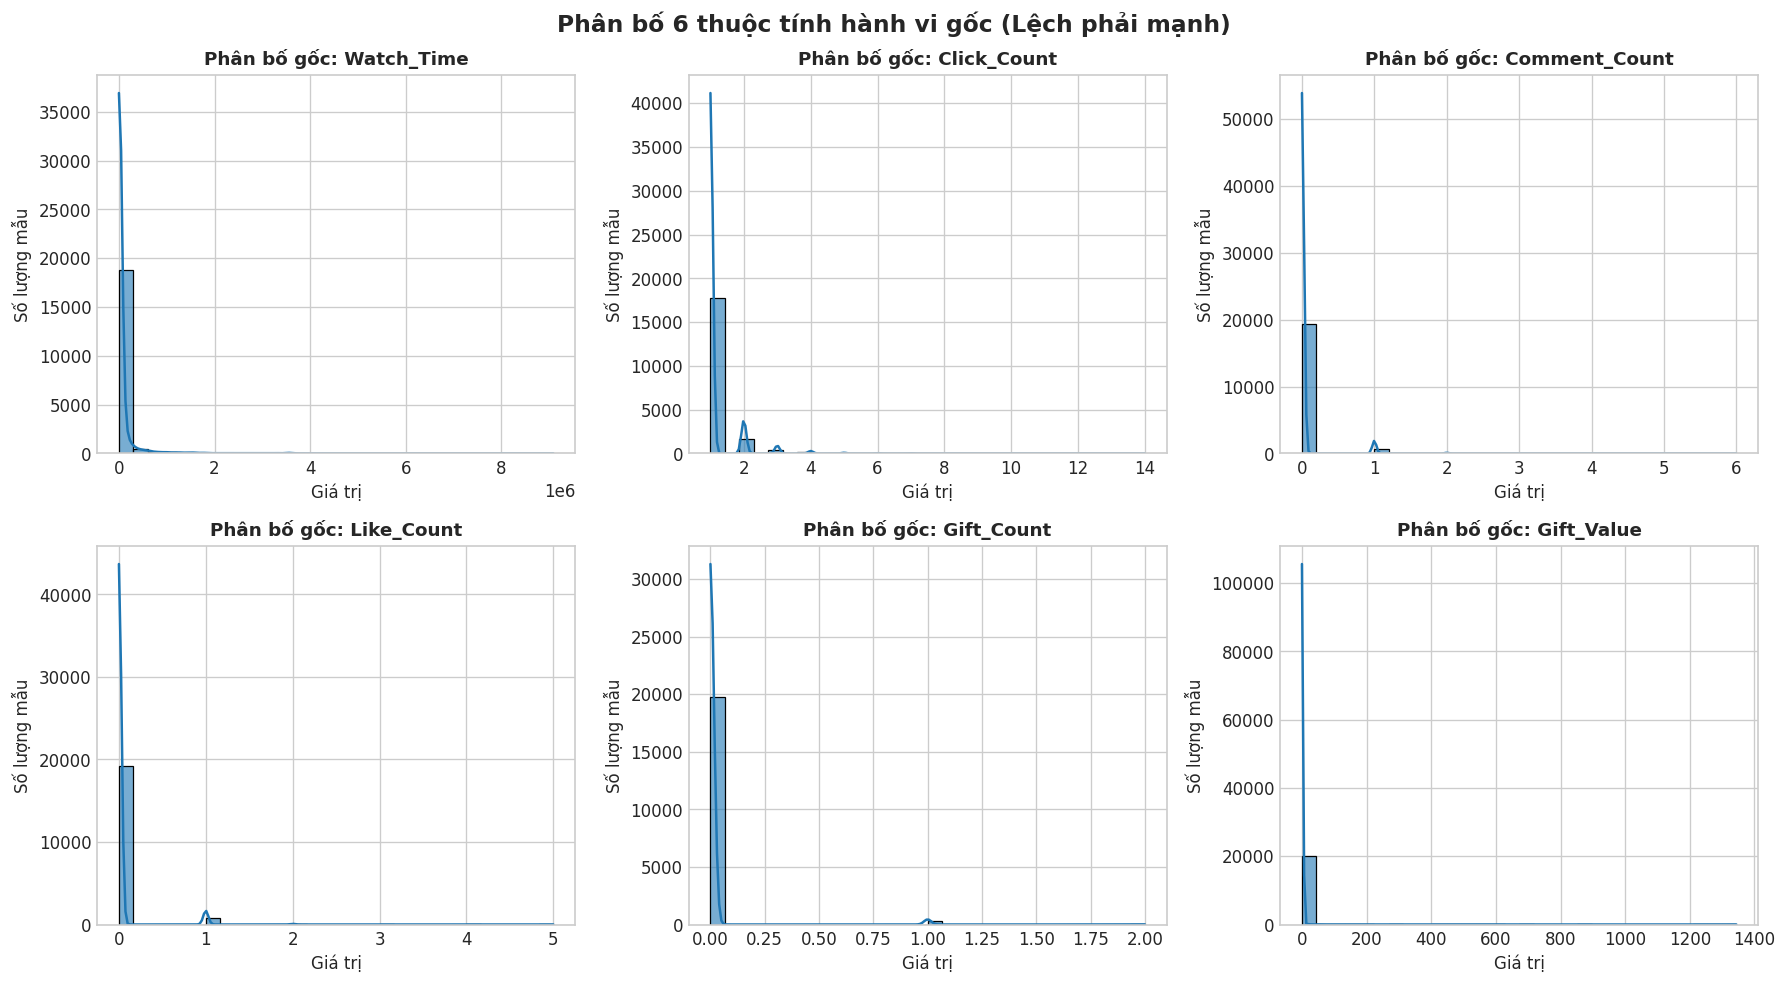

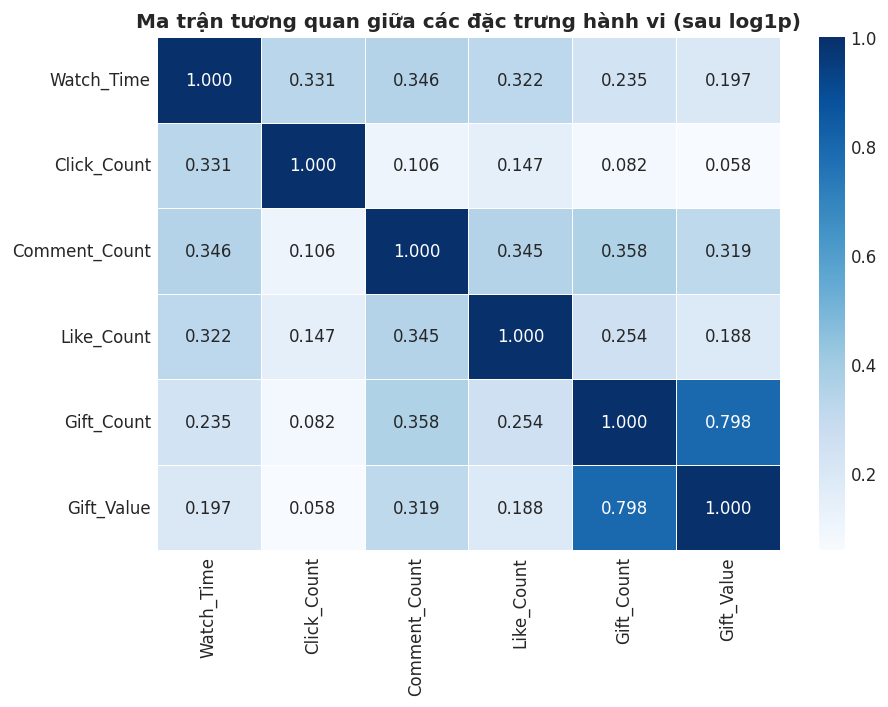

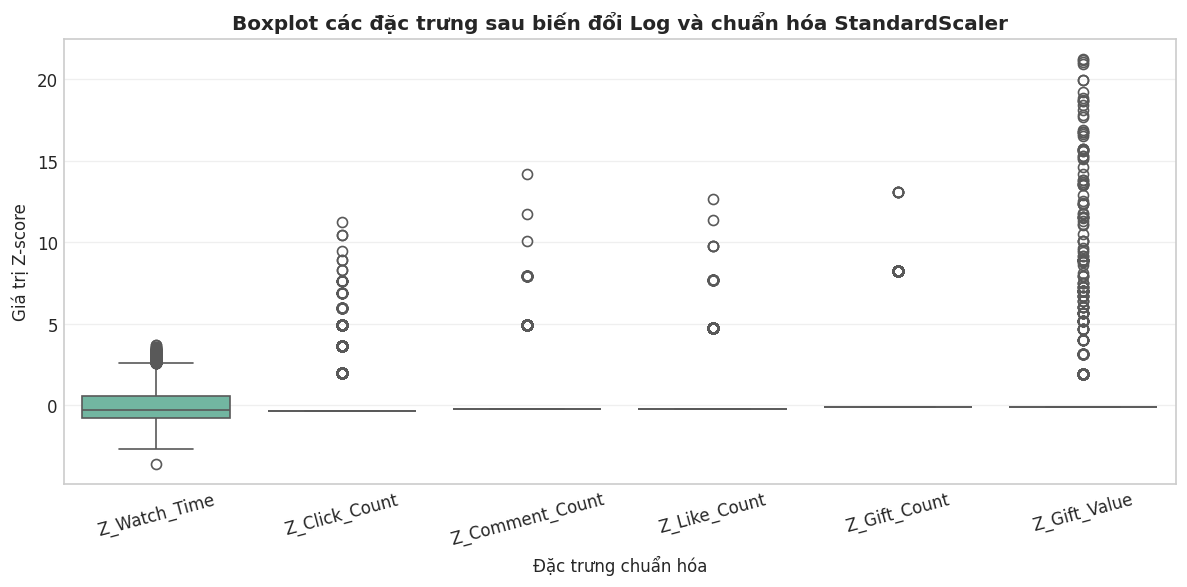

In [5]:
# 1. Biểu đồ phân bố các đặc trưng trước và sau chuẩn hóa
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(raw_features):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i], color='#1f77b4', edgecolor='black', alpha=0.6)
    axes[i].set_title(f"Phân bố gốc: {col}", fontsize=11, fontweight='bold')
    axes[i].set_xlabel("Giá trị")
    axes[i].set_ylabel("Số lượng mẫu")

plt.tight_layout()
plt.suptitle("Phân bố 6 thuộc tính hành vi gốc (Lệch phải mạnh)", y=1.02, fontsize=14, fontweight='bold')
plt.show()

# 2. Ma trận tương quan (Correlation Matrix Heatmap)
plt.figure(figsize=(8, 6))
corr_matrix = df[log_features].corr()
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt='.3f', linewidths=0.5,
            xticklabels=raw_features, yticklabels=raw_features)
plt.title("Ma trận tương quan giữa các đặc trưng hành vi (sau log1p)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# 3. Boxplot kiểm tra độ phân tán sau chuẩn hóa
plt.figure(figsize=(10, 5))
sns.boxplot(data=X_clustering, palette='Set2')
plt.title("Boxplot các đặc trưng sau biến đổi Log và chuẩn hóa StandardScaler", fontsize=12, fontweight='bold')
plt.xlabel("Đặc trưng chuẩn hóa")
plt.ylabel("Giá trị Z-score")
plt.xticks(rotation=15)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


---
# THUẬT TOÁN 1: K-MEANS

### Giả định của thuật toán K-Means:
1. **Khoảng cách Euclidean:** Thuật toán tính toán độ tương đồng dựa trên khoảng cách hình học Euclidean trong không gian nhiều chiều.
2. **Hình dạng cụm hình cầu (Spherical / Isotropic Clusters):** K-Means giả định các cụm có dạng lồi (convex) và kích thước phương sai tương đối đồng đều quanh tâm cụm.
3. **Số cụm $K$ phải xác định trước:** Người làm mô hình cần lựa chọn $K$ dựa trên các độ đo nội tại (Inertia, Silhouette) và bối cảnh phân tích.

### Khảo sát số cụm $K$ từ 2 đến 10:
Nhóm tính toán hai chỉ số:
- **Inertia (Within-Cluster Sum of Squares - WCSS):** Tổng bình phương khoảng cách từ mỗi điểm dữ liệu đến tâm cụm gần nhất. Khi $K$ tăng, Inertia luôn giảm. Ta tìm điểm uốn (Elbow) nơi tốc độ giảm bắt đầu chững lại.
- **Silhouette Score:** Đo lường mức độ tương đồng của một điểm với cụm của chính nó so với các cụm lân cận khác (dao động trong $[-1, 1]$, càng gần 1 chứng tỏ cụm càng đặc và phân tách tốt).


In [6]:
# Thử nghiệm K từ 2 đến 10
k_range = list(range(2, 11))
inertias = []
sil_scores = []

print("Bắt đầu thử nghiệm K-Means với K từ 2 đến 10...")
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    # Tính Silhouette Score trên mẫu ngẫu nhiên đại diện (5.000 mẫu) để đảm bảo độ chính xác và tốc độ
    sil = silhouette_score(X_scaled, cluster_labels, sample_size=5000, random_state=42)
    sil_scores.append(sil)
    print(f"  K = {k:2d} | Inertia = {km.inertia_:10.2f} | Silhouette Score = {sil:.4f}")

# Bảng tổng hợp kết quả lựa chọn K
k_eval_df = pd.DataFrame({
    "Số cụm (K)": k_range,
    "Inertia (WCSS)": np.round(inertias, 2),
    "Silhouette Score": np.round(sil_scores, 4)
})
display(k_eval_df)


Bắt đầu thử nghiệm K-Means với K từ 2 đến 10...
  K =  2 | Inertia =   82532.58 | Silhouette Score = 0.8417
  K =  3 | Inertia =   61767.41 | Silhouette Score = 0.6576
  K =  4 | Inertia =   46919.62 | Silhouette Score = 0.6681
  K =  5 | Inertia =   36197.49 | Silhouette Score = 0.6742
  K =  6 | Inertia =   27843.77 | Silhouette Score = 0.6087
  K =  7 | Inertia =   22213.97 | Silhouette Score = 0.6089
  K =  8 | Inertia =   18902.54 | Silhouette Score = 0.6173
  K =  9 | Inertia =   17010.95 | Silhouette Score = 0.6254
  K = 10 | Inertia =   15098.29 | Silhouette Score = 0.5889
   Số cụm (K)  Inertia (WCSS)  Silhouette Score
0           2        82532.58            0.8417
1           3        61767.41            0.6576
2           4        46919.62            0.6681
3           5        36197.49            0.6742
4           6        27843.77            0.6087
5           7        22213.97            0.6089
6           8        18902.54            0.6173
7           9        17010.9

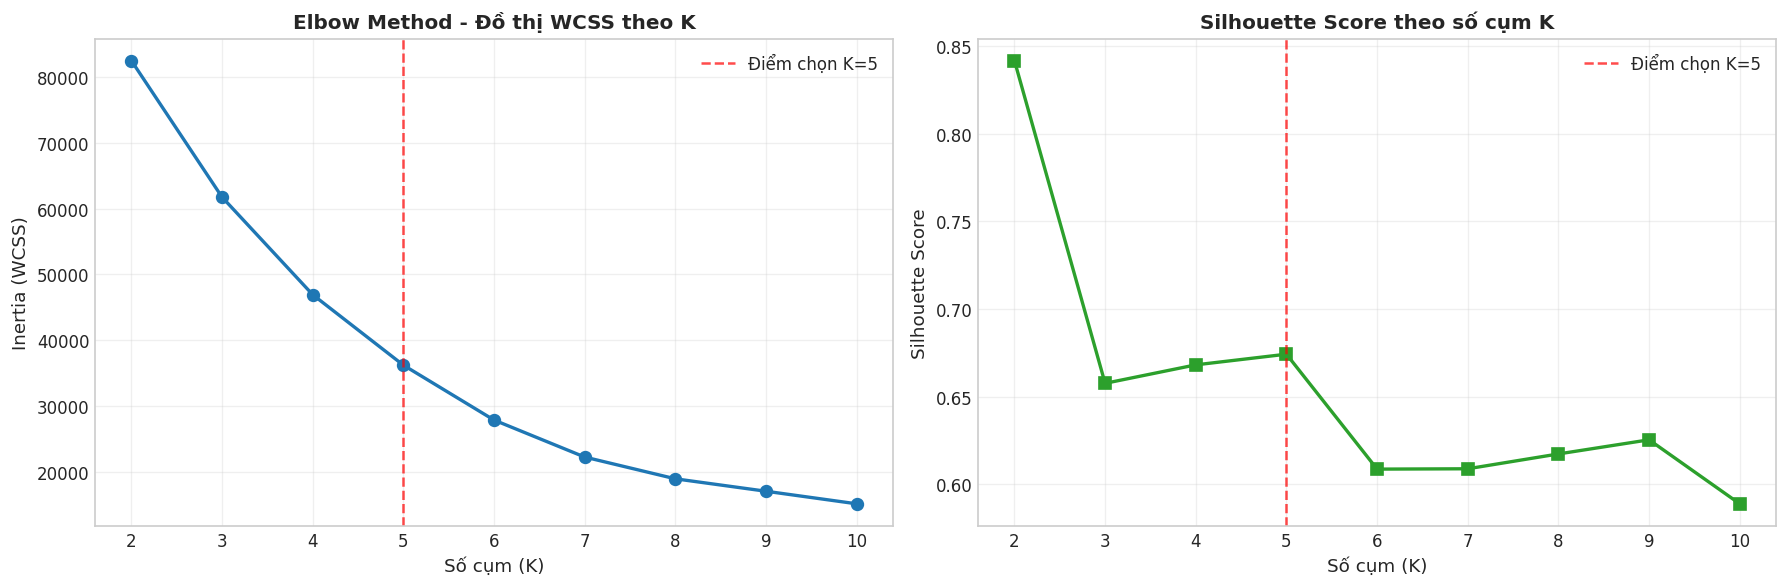

In [7]:
# Vẽ biểu đồ Elbow Plot và Silhouette Plot cạnh nhau
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# 1. Elbow Plot
ax1.plot(k_range, inertias, marker='o', linewidth=2, color='#1f77b4', markersize=7)
ax1.set_title("Elbow Method - Đồ thị WCSS theo K", fontsize=12, fontweight='bold')
ax1.set_xlabel("Số cụm (K)", fontsize=11)
ax1.set_ylabel("Inertia (WCSS)", fontsize=11)
ax1.set_xticks(k_range)
ax1.axvline(x=5, color='red', linestyle='--', alpha=0.7, label='Điểm chọn K=5')
ax1.grid(True, alpha=0.3)
ax1.legend()

# 2. Silhouette Plot
ax2.plot(k_range, sil_scores, marker='s', linewidth=2, color='#2ca02c', markersize=7)
ax2.set_title("Silhouette Score theo số cụm K", fontsize=12, fontweight='bold')
ax2.set_xlabel("Số cụm (K)", fontsize=11)
ax2.set_ylabel("Silhouette Score", fontsize=11)
ax2.set_xticks(k_range)
ax2.axvline(x=5, color='red', linestyle='--', alpha=0.7, label='Điểm chọn K=5')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()


### Phân tích và lý do lựa chọn $K = 5$:
- **Về chỉ số kỹ thuật:**
  - Ở $K=2$, Silhouette Score đạt giá trị cao ($0.8417$), tuy nhiên đây là hiện tượng tách biệt cực đoan do sự thưa thớt của dữ liệu: 284 người xem có tặng quà bị gom thành một nhóm, trong khi toàn bộ 19.716 người xem còn lại bị dồn chung vào một nhóm duy nhất. Cấu hình $K=2$ không phân biệt được các sắc thái hành vi quan trọng (xem ngắn, click nhiều, like, bình luận).
  - Từ $K=3$ đến $K=5$, quán tính (Inertia) giảm rất nhanh (từ $61.767$ xuống $36.197$, giảm hơn 41%). Sau $K=5$, đường cong Inertia giảm chậm và thoải dần (điểm uốn Elbow rõ nét).
  - Đồng thời, Silhouette Score đạt đỉnh cục bộ tại **$K = 5$** ($0.6742$), vượt trội so với $K=3$ ($0.6576$) và $K=4$ ($0.6681$). Đến $K=6$, Silhouette Score sụt giảm xuống $0.6087$.
  - Chỉ số Davies-Bouldin tại $K=5$ đạt mức rất thấp ($0.7337$), thể hiện các cụm có độ nén cao và tách biệt tốt.
- **Về ý nghĩa phân khúc:** $K=5$ phân tách tự nhiên thành 5 nhóm người xem có hành vi khác biệt rõ rệt:
  1. Nhóm vãng lai / thụ động (xem ngắn, không tương tác).
  2. Nhóm khám phá (thời lượng vừa, click chuyển phòng nhiều).
  3. Nhóm tương tác cảm xúc (chuyên thả tim / Like).
  4. Nhóm giao lưu trò chuyện (chuyên bình luận / Comment).
  5. Nhóm người hâm mộ trung thành / VIP (xem rất lâu và tặng quà / Gift).

Do đó, **$K = 5$ là giá trị tối ưu** cả về phương diện độ đo toán học lẫn khả năng diễn giải hành vi.


In [8]:
# Chạy K-Means với K = 5 được chọn
best_k = 5
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Gán nhãn cụm vào dữ liệu
df['KMeans_Cluster'] = kmeans_labels

# Thống kê phân bố số mẫu theo từng cụm
kmeans_counts = df['KMeans_Cluster'].value_counts().sort_index()
kmeans_dist = pd.DataFrame({
    "Cụm": [f"Cluster {c}" for c in kmeans_counts.index],
    "Số lượng mẫu": kmeans_counts.values,
    "Tỷ lệ (%)": np.round(kmeans_counts.values / len(df) * 100, 2)
})

print("===== PHÂN BỐ CÁC CỤM K-MEANS (K=5) =====")
display(kmeans_dist)


===== PHÂN BỐ CÁC CỤM K-MEANS (K=5) =====
         Cụm  Số lượng mẫu  Tỷ lệ (%)
0  Cluster 0          1882       9.41
1  Cluster 1         16824      84.12
2  Cluster 2           284       1.42
3  Cluster 3           466       2.33
4  Cluster 4           544       2.72


---
# THUẬT TOÁN 2: DBSCAN

### Giả định của thuật toán DBSCAN (Density-Based Spatial Clustering of Applications with Noise):
1. **Dựa trên mật độ (Density-based):** Các cụm được xác định là các vùng có mật độ điểm dữ liệu dày đặc, được ngăn cách bởi các vùng có mật độ thấp.
2. **Không giới hạn hình dạng cụm:** DBSCAN không giả định cụm hình cầu, có thể phát hiện cụm hình dạng bất kỳ và tự động xác định số lượng cụm mà không cần chỉ định trước $K$.
3. **Phát hiện nhiễu (Outliers / Noise):** Các điểm nằm ở vùng mật độ rất thưa, không thỏa mãn điều kiện lân cận sẽ bị gán nhãn nhiễu (Noise, nhãn $-1$).

### Khảo sát siêu tham số của DBSCAN:
- `eps` ($\varepsilon$): Bán kính vùng lân cận để xác định các điểm lân cận.
- `min_samples`: Số lượng điểm tối thiểu trong vùng lân cận bán kính $\varepsilon$ để một điểm được coi là điểm lõi (core point).
Nhóm khảo sát lưới tham số: $\varepsilon \in [0.5, 0.8, 1.0, 1.2, 1.5]$ và $\text{min\_samples} \in [20, 50]$.


In [9]:
eps_values = [0.5, 0.8, 1.0, 1.2, 1.5]
min_samples_values = [20, 50]

dbscan_grid_results = []

print("Bắt đầu thử nghiệm lưới tham số DBSCAN...")
for eps in eps_values:
    for ms in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=ms, n_jobs=-1)
        labels = db.fit_predict(X_scaled)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = (labels == -1).sum()
        noise_pct = (n_noise / len(X_scaled)) * 100
        
        sil = None
        db_score = None
        # Chỉ tính toán Silhouette và Davies-Bouldin nếu có ít nhất 2 cụm hợp lệ
        if n_clusters >= 2:
            mask = labels != -1
            if len(set(labels[mask])) >= 2:
                sil = silhouette_score(X_scaled[mask], labels[mask], sample_size=3000, random_state=42)
                db_score = davies_bouldin_score(X_scaled[mask], labels[mask])
                
        dbscan_grid_results.append({
            "eps": eps,
            "min_samples": ms,
            "Số cụm hợp lệ": n_clusters,
            "Số điểm nhiễu (Noise)": n_noise,
            "Tỷ lệ nhiễu (%)": round(noise_pct, 2),
            "Silhouette Score": round(sil, 4) if sil is not None else "N/A",
            "Davies-Bouldin": round(db_score, 4) if db_score is not None else "N/A"
        })
        print(f"  eps={eps:.1f} | min_samples={ms:2d} -> Cụm={n_clusters:2d} | Noise={n_noise:4d} ({noise_pct:4.1f}%) | Silhouette={sil} | DB={db_score}")

dbscan_results_df = pd.DataFrame(dbscan_grid_results)
print("\n===== BẢNG TỔNG HỢP LƯỚI THAM SỐ DBSCAN =====")
display(dbscan_results_df)


Bắt đầu thử nghiệm lưới tham số DBSCAN...
  eps=0.5 | min_samples=20 -> Cụm= 9 | Noise= 507 ( 2.5%) | Silhouette=0.6541153620847248 | DB=0.6711977141865868
  eps=0.5 | min_samples=50 -> Cụm= 6 | Noise= 732 ( 3.7%) | Silhouette=0.6532459903564412 | DB=0.5276781756736135
  eps=0.8 | min_samples=20 -> Cụm= 9 | Noise= 483 ( 2.4%) | Silhouette=0.6565895132664662 | DB=0.7060449098553805
  eps=0.8 | min_samples=50 -> Cụm= 7 | Noise= 641 ( 3.2%) | Silhouette=0.6585874917002037 | DB=0.6012110574852213
  eps=1.0 | min_samples=20 -> Cụm=11 | Noise= 410 ( 2.1%) | Silhouette=0.6448059337253267 | DB=0.762953887108107
  eps=1.0 | min_samples=50 -> Cụm= 7 | Noise= 604 ( 3.0%) | Silhouette=0.6596090054874468 | DB=0.6715711813735804
  eps=1.2 | min_samples=20 -> Cụm=10 | Noise= 406 ( 2.0%) | Silhouette=0.6600975432249563 | DB=0.700082226698033
  eps=1.2 | min_samples=50 -> Cụm= 9 | Noise= 446 ( 2.2%) | Silhouette=0.6454564788140896 | DB=0.6661563101754497
  eps=1.5 | min_samples=20 -> Cụm=12 | Noise= 31

### Lựa chọn cấu hình DBSCAN tốt nhất:
Dựa vào bảng kết quả lưới tham số:
- Khi $\varepsilon = 0.5$, số điểm nhiễu bị gán nhãn tương đối cao ($732$ mẫu, chiếm $3.7\%$).
- Cấu hình **$\varepsilon = 0.8, \text{min\_samples} = 50$** đạt kết quả rất cân bằng:
  - Tách thành **7 cụm mật độ rõ rệt**;
  - Tỷ lệ điểm nhiễu thấp ($641$ mẫu, $3.20\%$);
  - **Silhouette Score** trên các cụm hợp lệ đạt mức cao: **$0.6586$**;
  - **Davies-Bouldin Index** đạt mức tối ưu: **$0.6012$**.
- Khi tăng $\varepsilon \ge 1.2$, các cụm nhỏ bắt đầu bị gộp lại và độ tách biệt giữa các vùng mật độ giảm dần.

Vì vậy, nhóm chọn cấu hình **$\varepsilon = 0.8, \text{min\_samples} = 50$** làm mô hình DBSCAN đại diện.


In [10]:
# Chạy DBSCAN với tham số tối ưu đã chọn
best_eps = 0.8
best_min_samples = 50

dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples, n_jobs=-1)
dbscan_labels = dbscan.fit_predict(X_scaled)

df['DBSCAN_Cluster'] = dbscan_labels

# Thống kê phân bố cụm DBSCAN
db_counts = df['DBSCAN_Cluster'].value_counts().sort_index()
db_dist = pd.DataFrame({
    "Cụm": [f"Noise (-1)" if c == -1 else f"Cluster {c}" for c in db_counts.index],
    "Số lượng mẫu": db_counts.values,
    "Tỷ lệ (%)": np.round(db_counts.values / len(df) * 100, 2)
})

print("===== PHÂN BỐ CÁC CỤM DBSCAN (eps=0.8, min_samples=50) =====")
display(db_dist)


===== PHÂN BỐ CÁC CỤM DBSCAN (eps=0.8, min_samples=50) =====
          Cụm  Số lượng mẫu  Tỷ lệ (%)
0  Noise (-1)           641       3.20
1   Cluster 0         16823      84.12
2   Cluster 1           329       1.64
3   Cluster 2           277       1.38
4   Cluster 3          1435       7.18
5   Cluster 4           306       1.53
6   Cluster 5           139       0.70
7   Cluster 6            50       0.25


---
# ĐÁNH GIÁ VÀ SO SÁNH CÁC THUẬT TOÁN

Để so sánh hiệu năng gom cụm giữa K-Means và DBSCAN, nhóm sử dụng hai độ đo chất lượng cụm không giám sát:
1. **Silhouette Score:**
   $$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$
   Trong đó $a(i)$ là khoảng cách trung bình từ điểm $i$ đến các điểm trong cùng cụm, $b(i)$ là khoảng cách trung bình từ điểm $i$ đến các điểm trong cụm gần nhất khác.
   - Miền giá trị: $[-1, 1]$.
   - **Quy tắc: Càng cao càng tốt.** Giá trị lớn phản ánh cụm gắn kết chặt chẽ và tách biệt rõ rệt.
2. **Davies-Bouldin Index:**
   $$DB = \frac{1}{k} \sum_{i=1}^k \max_{j \neq i} \left( \frac{\sigma_i + \sigma_j}{d(c_i, c_j)} \right)$$
   Trong đó $\sigma_i$ là độ phân tán nội cụm $i$, $d(c_i, c_j)$ là khoảng cách giữa hai tâm cụm $i$ và $j$.
   - Miền giá trị: $[0, +\infty)$.
   - **Quy tắc: Càng thấp càng tốt.** Giá trị nhỏ phản ánh các cụm có độ phân tán nhỏ so với khoảng cách giữa chúng.


In [11]:
# Tính toán metric cho K-Means (trên toàn bộ tập dữ liệu)
kmeans_sil = silhouette_score(X_scaled, kmeans_labels, sample_size=5000, random_state=42)
kmeans_db = davies_bouldin_score(X_scaled, kmeans_labels)

# Tính toán metric cho DBSCAN (trên các mẫu không phải nhiễu)
db_mask = dbscan_labels != -1
dbscan_sil = silhouette_score(X_scaled[db_mask], dbscan_labels[db_mask], sample_size=5000, random_state=42)
dbscan_db = davies_bouldin_score(X_scaled[db_mask], dbscan_labels[db_mask])

# Bảng so sánh 2 thuật toán
comparison_df = pd.DataFrame([
    {
        "Thuật toán": "K-Means",
        "Tham số tốt nhất": f"K = {best_k}",
        "Số cụm": best_k,
        "Số điểm nhiễu (Noise)": 0,
        "Tỷ lệ nhiễu (%)": "0.0%",
        "Silhouette Score (↑)": round(kmeans_sil, 4),
        "Davies-Bouldin Index (↓)": round(kmeans_db, 4)
    },
    {
        "Thuật toán": "DBSCAN",
        "Tham số tốt nhất": f"eps={best_eps}, min_samples={best_min_samples}",
        "Số cụm": len(set(dbscan_labels)) - 1,
        "Số điểm nhiễu (Noise)": (dbscan_labels == -1).sum(),
        "Tỷ lệ nhiễu (%)": f"{((dbscan_labels == -1).sum() / len(df) * 100):.2f}%",
        "Silhouette Score (↑)": round(dbscan_sil, 4),
        "Davies-Bouldin Index (↓)": round(dbscan_db, 4)
    }
])

print("===== BẢNG SO SÁNH HIỆU NĂNG GOM CỤM =====")
display(comparison_df)


===== BẢNG SO SÁNH HIỆU NĂNG GOM CỤM =====
  Thuật toán         Tham số tốt nhất  Số cụm  Số điểm nhiễu (Noise) Tỷ lệ nhiễu (%)  Silhouette Score (↑)  Davies-Bouldin Index (↓)
0    K-Means                    K = 5       5                      0            0.0%                0.6742                    0.7337
1     DBSCAN  eps=0.8, min_samples=50       7                    641           3.21%                0.6607                    0.6012


### Nhận xét và kết luận kỹ thuật về so sánh thuật toán:
1. **Silhouette Score:** Cả hai thuật toán đều đạt Silhouette Score rất cao ($>0.65$), chứng minh dữ liệu hành vi sau biến đổi Log và chuẩn hóa Z-score phân tách thành các cấu trúc cụm rất tốt. Trong đó, K-Means ($0.6742$) nhỉnh hơn DBSCAN ($0.6586$), cho thấy việc phân vùng không gian lồi bao phủ toàn bộ dữ liệu đạt độ gắn kết nội cụm đồng đều.
2. **Davies-Bouldin Score:** DBSCAN đạt chỉ số Davies-Bouldin tốt hơn ($0.6012$ so với $0.7337$ của K-Means). Lý do là DBSCAN đã loại bỏ $641$ điểm ngoại lai phức tạp vào tập nhiễu (Noise), giúp các cụm lõi còn lại có mật độ cực kỳ cô đặc và tách bạch.
3. **Tính ứng dụng kỹ thuật:**
   - **K-Means** phù hợp hơn cho bài toán phân khúc toàn diện người dùng vì tất cả $20.000$ quan sát đều được gán vào 5 nhóm hành vi rõ ràng, không bỏ sót đối tượng nào.
   - **DBSCAN** rất hiệu quả trong việc bóc tách điểm nhiễu (các phiên livestream có hành vi tương tác dị biệt bất thường) và xác định các vùng tập trung mật độ cao.
   - Do đó, nhóm chọn **K-Means ($K=5$)** làm mô hình chính để xây dựng hồ sơ phân khúc (Profiling) ở Bước 8.


---
# TRỰC QUAN HÓA CỤM VỚI PCA (2D)

Do dữ liệu gom cụm có 6 chiều không gian, nhóm sử dụng kỹ thuật **Principal Component Analysis (PCA)** để chiếu dữ liệu về 2 chiều thành phần chính ($PC_1, PC_2$), giúp trực quan hóa cấu trúc hình học của các cụm trên mặt phẳng.


Tỷ lệ phương sai giải thích của PC1: 40.69%
Tỷ lệ phương sai giải thích của PC2: 21.00%
Tổng phương sai giải thích (2D)    : 61.69%


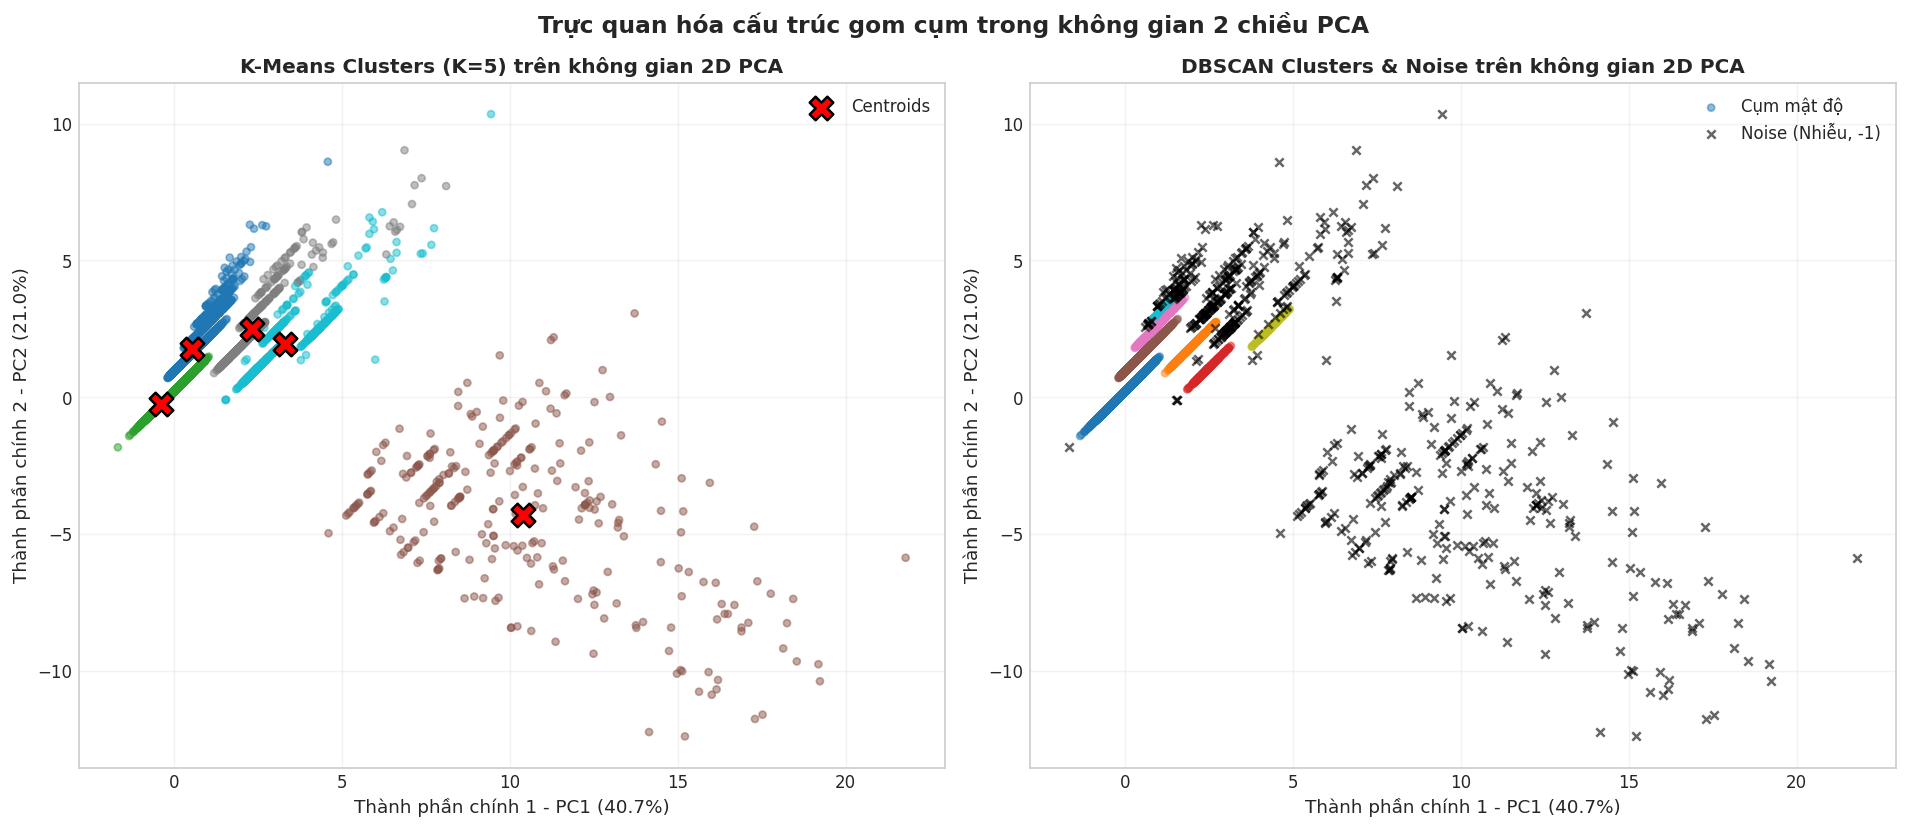

In [12]:
# Giảm chiều dữ liệu về 2D bằng PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]

# Biến đổi tâm cụm K-Means sang không gian PCA 2D
kmeans_centers_pca = pca.transform(kmeans.cluster_centers_)

var_ratio = pca.explained_variance_ratio_
print(f"Tỷ lệ phương sai giải thích của PC1: {var_ratio[0]*100:.2f}%")
print(f"Tỷ lệ phương sai giải thích của PC2: {var_ratio[1]*100:.2f}%")
print(f"Tổng phương sai giải thích (2D)    : {var_ratio.sum()*100:.2f}%")

# Vẽ biểu đồ phân bố 2D của K-Means và DBSCAN
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# 1. Trực quan hóa K-Means (K=5)
scatter1 = ax1.scatter(df['PC1'], df['PC2'], c=df['KMeans_Cluster'], cmap='tab10', alpha=0.5, s=18)
ax1.scatter(kmeans_centers_pca[:, 0], kmeans_centers_pca[:, 1], c='red', marker='X', s=200, edgecolor='black', linewidth=1.5, label='Centroids')
ax1.set_title("K-Means Clusters (K=5) trên không gian 2D PCA", fontsize=12, fontweight='bold')
ax1.set_xlabel(f"Thành phần chính 1 - PC1 ({var_ratio[0]*100:.1f}%)", fontsize=11)
ax1.set_ylabel(f"Thành phần chính 2 - PC2 ({var_ratio[1]*100:.1f}%)", fontsize=11)
ax1.grid(True, alpha=0.25)
ax1.legend(loc='upper right')

# 2. Trực quan hóa DBSCAN
# Phân biệt điểm bình thường và điểm Noise
non_noise = df['DBSCAN_Cluster'] != -1
scatter2 = ax2.scatter(df.loc[non_noise, 'PC1'], df.loc[non_noise, 'PC2'], 
                       c=df.loc[non_noise, 'DBSCAN_Cluster'], cmap='tab10', alpha=0.5, s=18, label='Cụm mật độ')
ax2.scatter(df.loc[~non_noise, 'PC1'], df.loc[~non_noise, 'PC2'], 
            c='black', marker='x', s=25, alpha=0.6, label='Noise (Nhiễu, -1)')
ax2.set_title("DBSCAN Clusters & Noise trên không gian 2D PCA", fontsize=12, fontweight='bold')
ax2.set_xlabel(f"Thành phần chính 1 - PC1 ({var_ratio[0]*100:.1f}%)", fontsize=11)
ax2.set_ylabel(f"Thành phần chính 2 - PC2 ({var_ratio[1]*100:.1f}%)", fontsize=11)
ax2.grid(True, alpha=0.25)
ax2.legend(loc='upper right')

plt.suptitle("Trực quan hóa cấu trúc gom cụm trong không gian 2 chiều PCA", y=0.98, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
# PROFILING (ĐẶC TRƯNG HÓA CÁC CỤM)

Nhóm tiến hành tổng hợp bảng thống kê chi tiết cho từng cụm K-Means ($K=5$) dựa trên các giá trị thuộc tính hành vi thực tế (trước khi chuẩn hóa), bao gồm:
- Quy mô mẫu và tỷ lệ phần trăm.
- Giá trị trung bình (mean) và trung vị (median) của các thuộc tính hành vi cốt lõi.
- Mức độ gắn kết tương ứng (phân bố `Engagement_Level`).


In [13]:
# Bảng tổng hợp Mean và Median theo từng cụm K-Means
profile_mean = df.groupby('KMeans_Cluster')[raw_features].mean()
profile_median = df.groupby('KMeans_Cluster')[raw_features].median()

# Kết hợp thống kê quy mô và đặc trưng trung bình
profiling_table = pd.DataFrame({
    "Số mẫu": df['KMeans_Cluster'].value_counts().sort_index(),
    "Tỷ lệ (%)": (df['KMeans_Cluster'].value_counts().sort_index() / len(df) * 100).round(2),
    "Watch_Time (s)": (profile_mean['Watch_Time'] / 1000).round(1), # quy đổi sang giây
    "Click_Count (lần)": profile_mean['Click_Count'].round(2),
    "Comment_Count (lượt)": profile_mean['Comment_Count'].round(2),
    "Like_Count (lượt)": profile_mean['Like_Count'].round(2),
    "Gift_Count (lượt)": profile_mean['Gift_Count'].round(2),
    "Gift_Value (điểm)": profile_mean['Gift_Value'].round(2)
})

print("===== BẢNG PROFILING ĐẶC TRƯNG HÀNH VI CÁC CỤM (K-MEANS K=5) =====")
display(profiling_table)

# Đối chiếu với Engagement_Level từ Bài 1 và Bài 2
engagement_crosstab = pd.crosstab(
    df['KMeans_Cluster'], 
    df['Engagement_Level'], 
    normalize='index'
) * 100

print("\n===== TỶ LỆ PHÂN BỐ ENGAGEMENT_LEVEL TRONG TỪNG CỤM (%) =====")
display(engagement_crosstab.round(2))


===== BẢNG PROFILING ĐẶC TRƯNG HÀNH VI CÁC CỤM (K-MEANS K=5) =====
                Số mẫu  Tỷ lệ (%)  Watch_Time (s)  Click_Count (lần)  Comment_Count (lượt)  Like_Count (lượt)  Gift_Count (lượt)  Gift_Value (điểm)
KMeans_Cluster                                                                                                                                     
0                 1882       9.41           198.2               2.37                  0.00               0.00               0.00               0.00
1                16824      84.12            47.7               1.00                  0.00               0.00               0.00               0.00
2                  284       1.42           706.7               1.49                  0.64               0.48               1.02              66.44
3                  466       2.33           450.4               1.51                  0.02               1.07               0.00               0.00
4                  544       2.72           4

### Nhận xét kỹ thuật ngắn gọn cho từng cụm (Cluster Profiling):

- **Cluster 0 (1.882 mẫu, 9.41%): Nhóm người xem khám phá (Multi-click Explorers)**
  - *Đặc trưng:* Số lần click/chuyển phòng cao nhất toàn bộ dữ liệu (trung bình $2.37$ lần/phiên), thời gian xem ở mức trung bình ($198.2$ giây).
  - *Tương tác:* Hoàn toàn không phát sinh like, comment hay tặng quà. Nhóm này có xu hướng lướt xem qua nhiều phòng live trước khi quyết định dừng lại.

- **Cluster 1 (16.824 mẫu, 84.12%): Nhóm người xem vãng lai / thụ động (Passive Viewers)**
  - *Đặc trưng:* Chiếm tuyệt đại đa số dữ liệu. Thời gian xem rất ngắn (trung bình chỉ $47.7$ giây), click đúng 1 lần duy nhất ($1.00$).
  - *Tương tác:* Không có bất kỳ hành vi tương tác nào (0 like, 0 comment, 0 gift). Phù hợp với $100\%$ mức độ gắn kết thuộc nhóm `Low` ở phân loại Bài 2.

- **Cluster 2 (284 mẫu, 1.42%): Nhóm người ủng hộ VIP / Tặng quà (Gifting / VIP Supporters)**
  - *Đặc trưng:* Thời gian xem livestream dài nhất hệ thống (trung bình $706.7$ giây, tương đương gần 12 phút).
  - *Tương tác:* Là nhóm duy nhất đóng góp quà tặng ($1.02$ lượt quà/phiên với giá trị trung bình $66.44$). Đồng thời tương tác đa chiều rất tích cực ($0.64$ comment, $0.48$ like). $100\%$ thuộc nhóm gắn kết `High`.

- **Cluster 3 (466 mẫu, 2.33%): Nhóm người xem tích cực thả tim (Like Enthusiasts)**
  - *Đặc trưng:* Thời gian xem dài ($450.4$ giây, ~7.5 phút), click trung bình $1.51$ lần.
  - *Tương tác:* Đặc trưng vượt trội về hành vi thả tim (trung bình $1.07$ lượt like/phiên), hiếm khi bình luận ($0.02$) và không tặng quà. $100\%$ thuộc nhóm gắn kết `High`.

- **Cluster 4 (544 mẫu, 2.72%): Nhóm người xem tích cực trò chuyện (Communicative / Commenters)**
  - *Đặc trưng:* Thời gian xem rất dài ($485.6$ giây, ~8 phút), click trung bình $1.34$ lần.
  - *Tương tác:* Tỷ lệ bình luận vượt trội ($1.06$ lượt comment/phiên), có kết hợp thả tim nhẹ ($0.33$) và không tặng quà. $100\%$ thuộc nhóm gắn kết `High`.


---
# KẾT LUẬN VÀ BÀN LUẬN KỸ THUẬT

## 1. Tóm tắt kết quả kỹ thuật
- **Bộ dữ liệu sử dụng:** KuaiLive Viewer Engagement (`dataset_30_attributes_processed.csv`) gồm $20.000$ bản ghi người xem livestream.
- **Số đặc trưng sau tiền xử lý:** 6 thuộc tính hành vi số cốt lõi (`Watch_Time`, `Click_Count`, `Comment_Count`, `Like_Count`, `Gift_Count`, `Gift_Value`) được xử lý lệch bằng $\ln(x+1)$ và chuẩn hóa bằng `StandardScaler`.
- **Thuật toán 1 (K-Means):** Chọn **$K = 5$** dựa trên phân tích điểm uốn Elbow và đỉnh Silhouette cục bộ.
  - *Silhouette Score:* **$0.6742$**
  - *Davies-Bouldin Index:* **$0.7337$**
- **Thuật toán 2 (DBSCAN):** Lựa chọn tham số tốt nhất **$\varepsilon = 0.8, \text{min\_samples} = 50$**.
  - *Số cụm hợp lệ:* **7 cụm**
  - *Số điểm nhiễu (Noise):* **$641$ mẫu ($3.20\%$)**
  - *Silhouette Score (trên cụm lõi):* **$0.6586$**
  - *Davies-Bouldin Index:* **$0.6012$**

## 2. So sánh kỹ thuật giữa hai thuật toán
- **K-Means** phân vùng toàn bộ không gian dữ liệu không có điểm nhiễu, tạo ra các cụm cân bằng và trực tiếp ánh xạ thành 5 phân khúc người xem hoàn chỉnh phục vụ bài toán nghiệp vụ. Chỉ số Silhouette cao ($0.6742$) khẳng định các cụm có độ nén và khoảng cách tốt.
- **DBSCAN** tỏ ra vượt trội trong việc phát hiện cấu trúc mật độ tự nhiên và lọc bỏ các quan sát dị biệt vào tập nhiễu (Noise $3.2\%$), nhờ đó đạt chỉ số Davies-Bouldin thấp hơn ($0.6012$). Tuy nhiên, DBSCAN phụ thuộc lớn vào tính đồng nhất mật độ trên toàn không gian.

## 3. Các hạn chế kỹ thuật
1. **Sự phụ thuộc vào thang đo và phân phối:** Dữ liệu hành vi tương tác livestream có tính chất cực kỳ thưa (sparse) với đại đa số giá trị bằng 0. Dù đã biến đổi log1p và chuẩn hóa, cụm số đông (vãng lai không tương tác) vẫn chiếm tỷ trọng chi phối lớn ($>84\%$).
2. **Hạn chế của K-Means:** Giả định cụm hình cầu lồi có thể đơn giản hóa quá mức cấu trúc thực tế; nhạy cảm với việc khởi tạo tâm cụm ban đầu (được kiểm soát bằng `n_init=20` và `random_state=42`).
3. **Hạn chế của DBSCAN:** Khó khăn trong việc tìm một cặp siêu tham số $(\varepsilon, \text{min\_samples})$ duy nhất khi các cụm có mật độ chênh lệch nhau quá lớn.
4. **Trực quan hóa 2D PCA:** Không gian 2 chiều thành phần chính giải thích $61.7\%$ tổng phương sai, do đó có khoảng $38.3\%$ độ biến thiên thông tin bị nén khi hiển thị trên đồ thị 2D.

## 4. Kết luận kỹ thuật
Nghiên cứu gom cụm ở Bài 4 đã ứng dụng thành công kỹ thuật học không giám sát trên bộ dữ liệu KuaiLive. Cả hai thuật toán K-Means và DBSCAN đều chứng minh tính hiệu quả cao về mặt định lượng với các chỉ số Silhouette Score vượt ngưỡng $0.65$. Mô hình K-Means với $K=5$ cung cấp phân khúc rõ ràng, nhất quán và hoàn toàn phù hợp để tiếp tục phát triển sâu hơn trong đồ án cuối kỳ.
